### 결과 해석, 의사 결정
- 통계 분석 목적 -> 더 나은 결정 내리려고 하는것
- 매출 건수로 매출 금액 예측
- 매출 금액이 목표라면, 손님이 얼마나 필요한지를 예측하는 것이 회귀다

In [2]:
# 상권 매출을 시각화 해서 비교
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import pandas as pd
from scipy import stats

df = pd.read_csv("../data/07-8_seoul_market_sales.csv")
df.head(3)



,기준_년분기_코드,상권_구분_코드_명,상권_코드_명,서비스_업종_코드_명,당월_매출_금액,당월_매출_건수,주중_매출_금액,주말_매출_금액,남성_매출_금액,여성_매출_금액,연령대_10_매출_금액,연령대_20_매출_금액,연령대_30_매출_금액,연령대_40_매출_금액,연령대_50_매출_금액,연령대_60_이상_매출_금액
0,20254,발달상권,"신촌역(신촌역, 신촌로터리)",스포츠 강습,190574012,563,185879107,4694905,62004846,122818273,1578072,62149177,70583498,12783010,35309971,2419391
1,20254,전통시장,동화동 골목형상점가,미용실,241121913,7596,158201210,82920703,110263603,126565631,689103,17374758,40986830,66989251,63290864,47498428
2,20254,전통시장,노량진중앙시장,커피-음료,143339677,43869,95844027,47495650,84490667,57487331,2121862,42653948,43692418,15772423,24945022,12792323


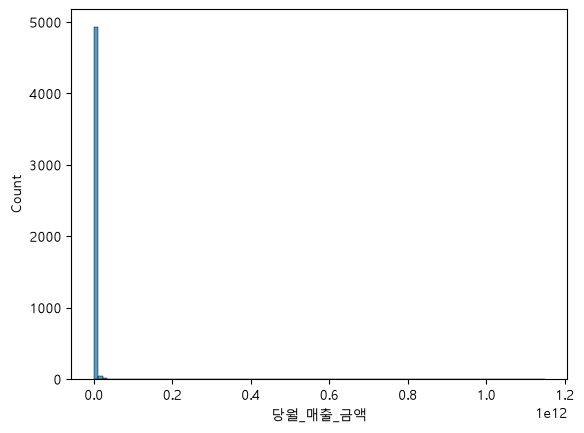

In [3]:

import matplotlib.pyplot as plt

# 한글 폰트 설정 (Windows 기본 폰트인 맑은 고딕 사용)
plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False


sns.histplot(df['당월_매출_금액'], bins=100)
plt.show()

In [4]:
r = stats.linregress(df['당월_매출_건수'],df['당월_매출_금액'])
r

LinregressResult(slope=np.float64(57053.17611447167), intercept=np.float64(-918829232.2231295), rvalue=np.float64(0.8605464150264389), pvalue=np.float64(0.0), stderr=np.float64(477.68598196020986), intercept_stderr=np.float64(135427782.0477985))

In [5]:
target_sales = 200_000_000
need_count = (target_sales - r.intercept) / r.slope
print(need_count)

19610.288303289322


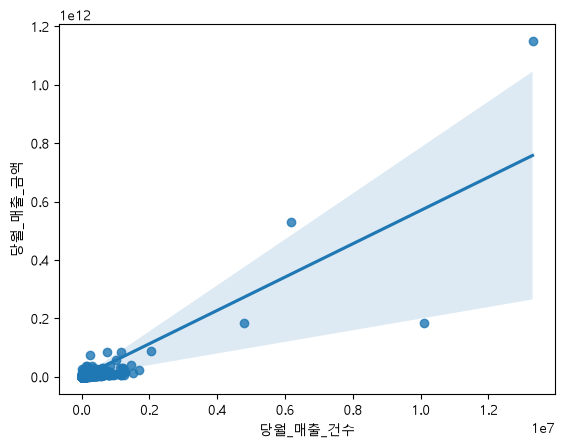

In [6]:
sns.regplot(data=df,
            x="당월_매출_건수",
            y="당월_매출_금액"
            )
plt.show()            

In [8]:
#  회귀식을 구했으니까 건수를 알면 매출도 예상 가능

data = pd.read_csv("../data/07-1_study_habits.csv")
data.head()



,반,성별,공부시간,시험점수,용돈
0,C,여,2.7,63,11000
1,A,남,1.8,69,23000
2,C,남,3.5,74,27000
3,C,여,2.0,74,6000
4,A,여,3.2,64,25000


In [11]:
import statsmodels.formula.api as smf

model = smf.ols("시험점수 ~ 공부시간 + 용돈", data=data).fit()

In [12]:
print(model.rsquared)

0.6198339491711912


In [13]:
model.params

Intercept    57.386951
공부시간          3.983828
용돈           -0.000042
dtype: float64

In [14]:
model.pvalues

Intercept    2.276802e-66
공부시간         3.551190e-26
용돈           1.789752e-01
dtype: float64